Imports

In [17]:

import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import Dataset, DataLoader
%matplotlib inline
from PIL import Image
import albumentations as A
import cv2

Downloading Data

In [2]:
mnist_data = torchvision.datasets.MNIST(root='',
download=True)


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:01<00:00, 6.67MB/s]


Extracting MNIST\raw\train-images-idx3-ubyte.gz to MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 224kB/s]


Extracting MNIST\raw\train-labels-idx1-ubyte.gz to MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 2.02MB/s]


Extracting MNIST\raw\t10k-images-idx3-ubyte.gz to MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]

Extracting MNIST\raw\t10k-labels-idx1-ubyte.gz to MNIST\raw



In [4]:
# get a random sample from the train dataset
def get_single_sample(dataset_object: Dataset, sample_index = None):
  if type(sample_index) == type(None):
      # np.random.seed(1234) # for sanity check
      sample_index = np.random.randint(0, len(dataset_object))
  if not isinstance(sample_index, int):
    raise TypeError(f'expected type of sample index (if provided )is int, yet {type(sample_index) = }')
  img2augment, label2 = dataset_object[sample_index][0], dataset_object[sample_index][1]
  return img2augment, label2, sample_index

5 Examples

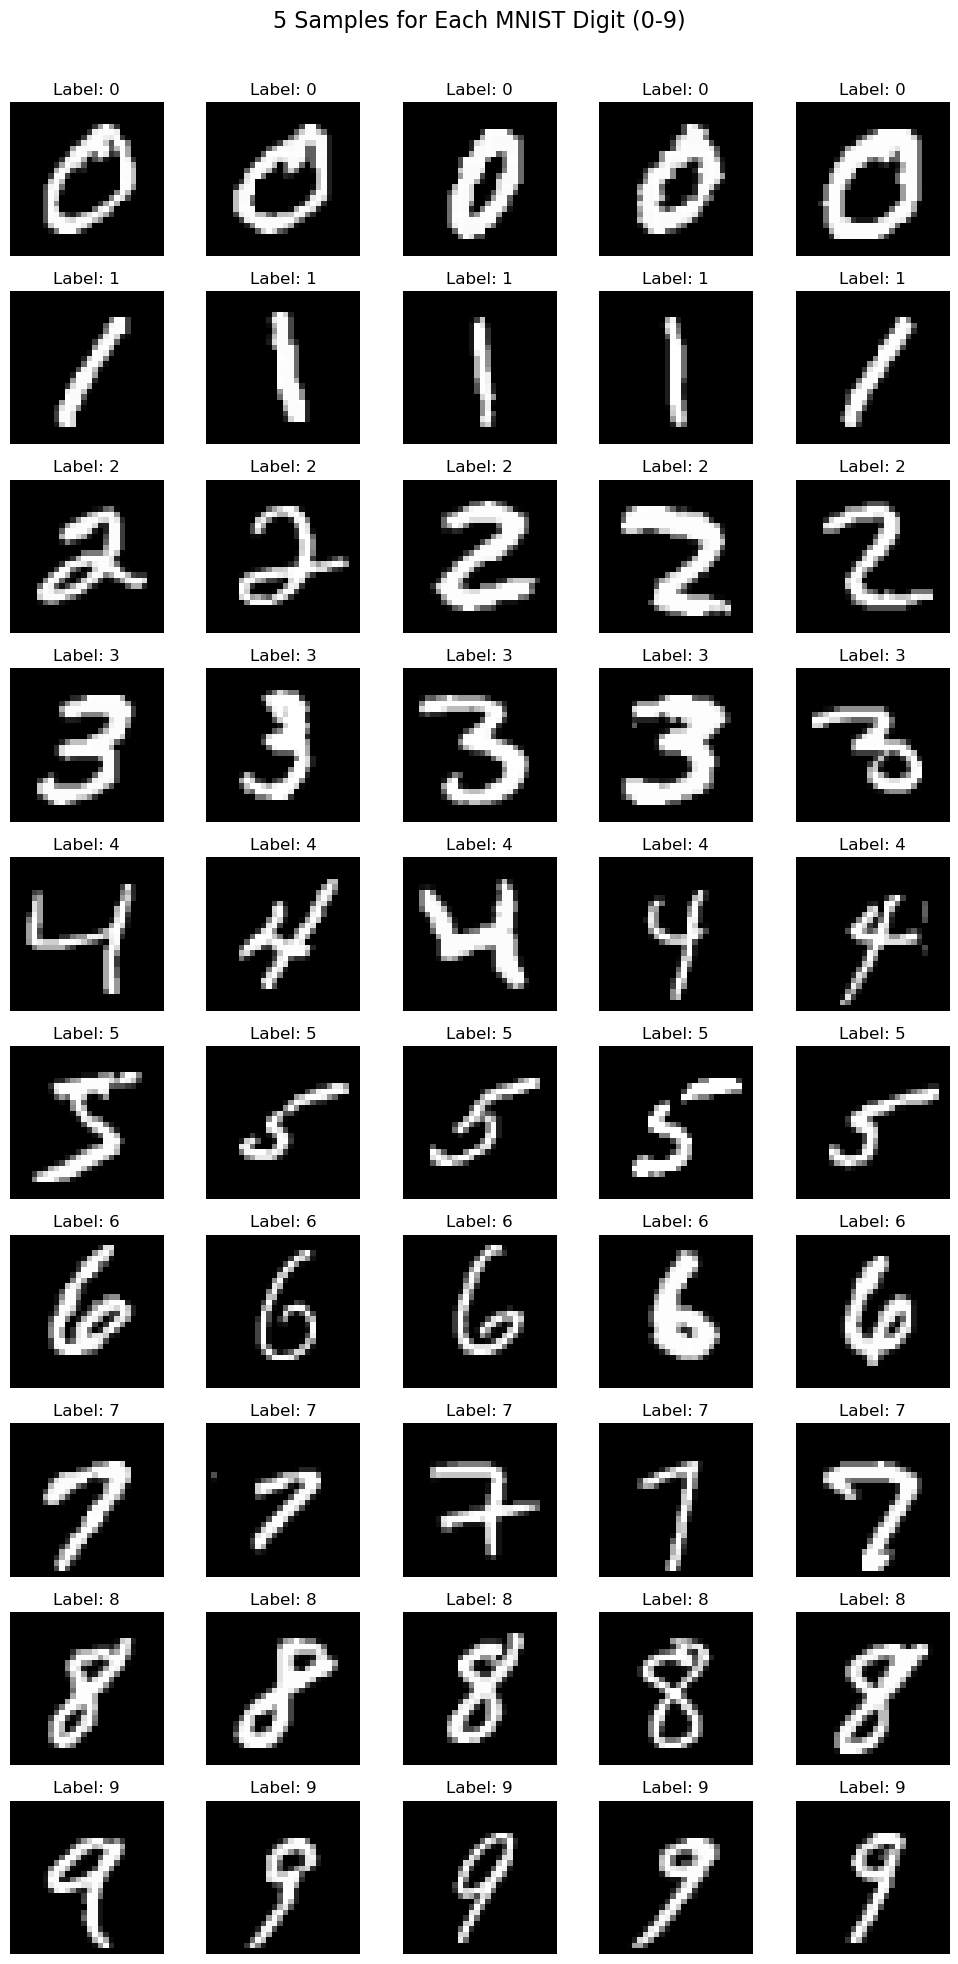

In [12]:
# Build a dictionary of 5 samples per class
samples_per_class = {i: [] for i in range(10)}
i = 0
while any(len(v) < 5 for v in samples_per_class.values()):
    img, label = mnist_data[i][0], mnist_data[i][1]
    if len(samples_per_class[label]) < 5:
        samples_per_class[label].append(img)
    i += 1

# Plotting
fig, axes = plt.subplots(10, 5, figsize=(10, 20))
fig.suptitle('5 Samples for Each MNIST Digit (0-9)', fontsize=16)

for label in range(10):
    for j in range(5):
        ax = axes[label][j]
        ax.imshow(samples_per_class[label][j], cmap='gray')
        ax.set_title(f"Label: {label}")
        ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.97])  # Leave space for suptitle
plt.show()

In [13]:
def get_digit_images_by_label(dataset):
    label_dict = {i: [] for i in range(10)}
    for img, label in dataset:
        label_dict[label].append(img)
    return label_dict

In [14]:
# Combine 3 digits into a single 28x84 image
def create_combined_image(img1, img2, img3):
    new_img = Image.new('L', (28 * 3, 28))  # 'L' = 8-bit pixels, black and white
    new_img.paste(img1, (0, 0))
    new_img.paste(img2, (28, 0))
    new_img.paste(img3, (56, 0))
    return new_img

In [15]:
# Apply augmentation after combining
def apply_augmentation(pil_img, augmenter):
    img_array = np.array(pil_img)
    augmented = augmenter(image=img_array)
    return Image.fromarray(augmented['image']) ##convert back to PIL

In [18]:
# Main generation loop
def generate_augmented_dataset(mnist_data, augmenter, samples_per_class=4000):
    by_label = get_digit_images_by_label(mnist_data)
    new_data = []
    new_labels = []
    
    for class_id in range(101):  # 000 to 100
        str_label = f"{class_id:03d}"
        digit_triplet = [int(c) for c in str_label]
        for _ in range(samples_per_class):
            imgs = [random.choice(by_label[d]) for d in digit_triplet]
            combined_img = create_combined_image(*imgs)
            augmented_img = apply_augmentation(combined_img, augmenter)
            new_data.append(augmented_img)
            new_labels.append(class_id)
    
    return new_data, new_labels  # You might want to save as a custom Dataset class

Creating a new picture with *3 the width to fit all the digits.

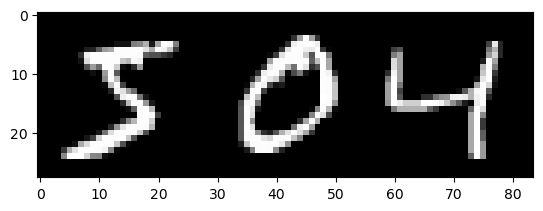

In [21]:
test_img1, _, _ = get_single_sample(mnist_data, 0)
test_img2, _, _ = get_single_sample(mnist_data, 1)
test_img3, _, _ = get_single_sample(mnist_data, 2)
test_combined_img = create_combined_image(test_img1, test_img2, test_img3)
plt.imshow(test_combined_img, 'gray')
plt.show()


Adding augmentations

In [27]:
mnist_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),                                 # 1 - Flip
    A.Rotate(limit=25, p=0.5),                               # 2 - Rotate (avoid 180!)
    A.GaussianBlur(blur_limit=(1, 3), p=0.3),                # 3 - Gaussian Blur
    A.Affine(scale=(0.9, 1.1), translate_percent=0.1, p=0.5),# 4 - Zoom & Translate
    A.ElasticTransform(alpha=1, sigma=50, p=0.3),            # 5 - Elastic Distortion
    A.GaussNoise(p=0.2),                                     # 6 - Gaussian Noise
    A.MedianBlur(blur_limit=3, p=0.3),                       # 7 - Median Blur
    A.RandomBrightnessContrast(p=0.3),                       # 8 - Lighten/Darken
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3), # 9 - Grid Warping
    A.RandomScale(scale_limit=0.2, p=0.3),                   # 10 -Scale up/down 20%
    #A.Resize(height=28, width=84),                           # 10 -Resize to match your combined width
    A.InvertImg(p=0.2),                                      # 11 - Invert colors (black ↔ white)
    A.CLAHE(p=0.2),                                          # 12 - Local histogram equalization
    A.RandomShadow(p=0.3),                                   # 13 - Fake lighting shadows
    A.Perspective(scale=(0.03, 0.06), p=0.3),                # 14 - Perspective warping
    A.CoarseDropout(p=0.3), # 15 - Random dropout
])

Need to change from PIL to NP in order to augment

In [28]:
def pil2np(img):
  if isinstance(img, Image.Image):
    return np.array(img)
  return img

Lets tests some 

sample_index =7955, type(img) = <class 'PIL.Image.Image'>,  label = 4, type(label) = <class 'int'>
sample_index =7955, type(augmented_img) = <class 'numpy.ndarray'>,  label = 4, type(label) = <class 'int'>


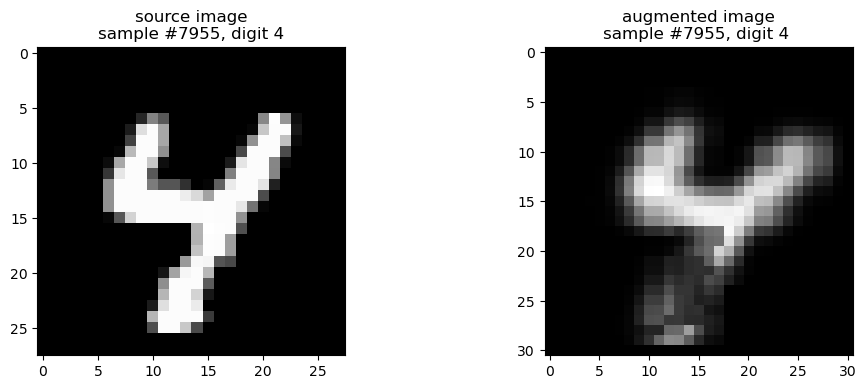

sample_index =45865, type(img) = <class 'PIL.Image.Image'>,  label = 7, type(label) = <class 'int'>
sample_index =45865, type(augmented_img) = <class 'numpy.ndarray'>,  label = 7, type(label) = <class 'int'>


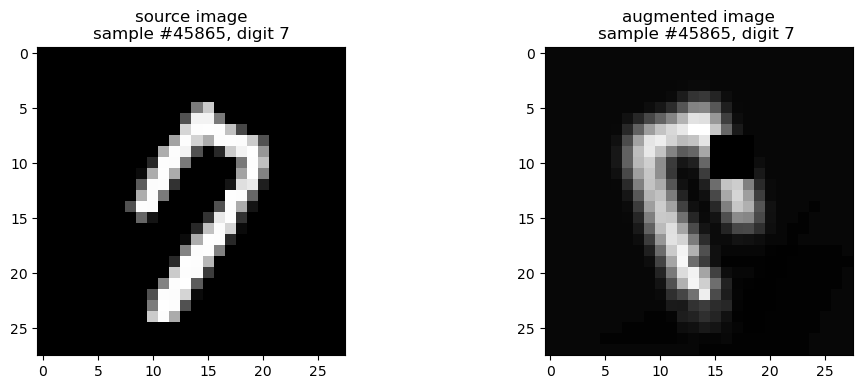

sample_index =41269, type(img) = <class 'PIL.Image.Image'>,  label = 1, type(label) = <class 'int'>
sample_index =41269, type(augmented_img) = <class 'numpy.ndarray'>,  label = 1, type(label) = <class 'int'>


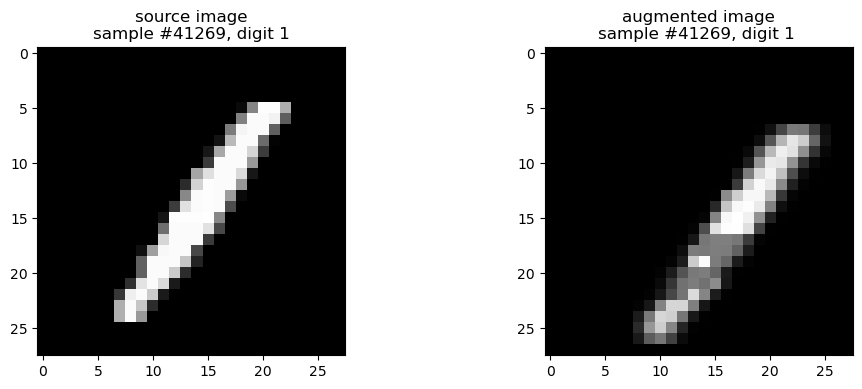

In [29]:
for _ in range(3):
  img, label, sample_index = get_single_sample(mnist_data)
  img_np = pil2np(img)

  print(f"{sample_index =}, {type(img) = },  {label = }, {type(label) = }")
  augmented_img = mnist_transforms(image=img_np)['image']
  print(f"{sample_index =}, {type(augmented_img) = },  {label = }, {type(label) = }")
  plt.figure(figsize=(12,4))
  plt.subplot(121)
  plt.imshow(img, 'gray')
  plt.title(f"source image\nsample #{sample_index}, digit {label}")
  plt.subplot(122)
  plt.imshow(augmented_img, 'gray')
  plt.title(f'augmented image\nsample #{sample_index}, digit {label} ')
  plt.show()

In [30]:
new_data,new_labels = generate_augmented_dataset(mnist_data, mnist_transforms)

In [31]:
def show_one_sample_per_class(data, labels, max_classes=101):
    class_to_image = {}
    
    for img, label in zip(data, labels):
        if label not in class_to_image:
            class_to_image[label] = img
        if len(class_to_image) >= max_classes:
            break

    sorted_keys = sorted(class_to_image.keys())
    num_classes = len(sorted_keys)

    cols = 13  # 13 x 8 = 104, enough space
    rows = (num_classes + cols - 1) // cols  # round up

    plt.figure(figsize=(cols * 1.2, rows * 1.2))
    
    for i, label in enumerate(sorted_keys):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(class_to_image[label], cmap='gray')
        plt.title(label, fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

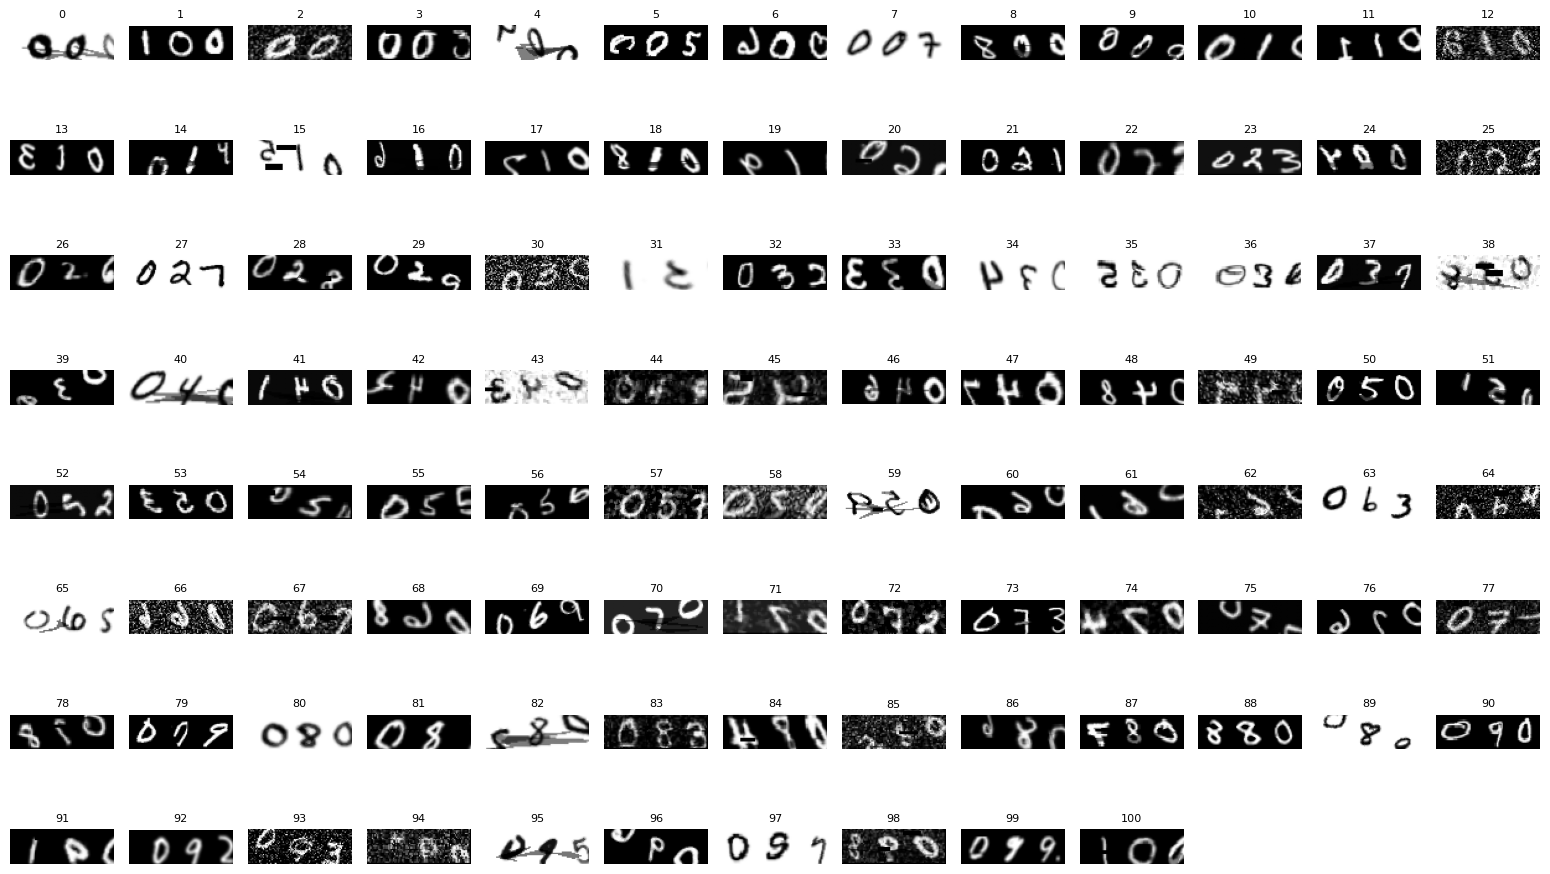

In [32]:
show_one_sample_per_class(new_data, new_labels)

DataBase class for the new Data


In [34]:
class MyMNISTDataset(Dataset): # inherits from torch build in Dataset class
  #   creates your dataset

  def __init__(self, img,labels, transforms=None):
    super(MyMNISTDataset, self).__init__()
    # data loading and splitting to data and labels
    self.xs = img
    self.ys = labels
    self.transforms = transforms

  def __getitem__(self, idx):  # allow indexing
    #   dataset[idx]

    x = self.xs[idx]# your code here
    y = self.ys[idx]# your code here
    return x, y

  def __len__(self):
    #   length of the dataset
    ds_len = len(self.xs)# Your code here
    return ds_len

In [35]:
MyMNISTDataset(new_data,new_labels)